# MScFE 622 — Stochastic Modeling: Group Work Project #1


**Objective.** The objective is to implement a full project workflow workflow: Heston calibration, Asian-option Monte Carlo pricing, Bates calibration, the 70-day put pricing task, and CIR term-structure calibration and simulation.

### Core assignment inputs
- Current SM stock price: \(S_0=\$232.90\)
- Constant annual risk-free rate: \(r=1.50\%\)
- 250 trading days per year
- Step 1 target maturity: 15 days
- Step 1(c) Asian call: 20 days, ATM
- Step 2 target maturity: 60 days
- Step 2(c) put: 70 days, 95% moneyness
- Step 3: Euribor term structure, cubic-spline interpolation, CIR calibration, and 100,000 Monte Carlo simulations.

The assignment requires market-price calibration using MSE, Fourier pricing for the Heston/Bates tasks, Monte Carlo pricing for the Asian/put tasks, and graphs and interpretations suitable for the technical report.




## Model roadmap

The project has three linked stages:

1. **Short-dated equity options:** calibrate Heston to 15-day market prices.
2. **Asian option:** use the calibrated risk-neutral dynamics to price a 20-day ATM Asian call.
3. **Medium-dated equity options:** calibrate Bates to 60-day market prices and use it for the 70-day put.
4. **Interest-rate risk:** construct the Euribor term structure, interpolate weekly rates, calibrate CIR, and simulate the future 12-month Euribor.

The diagram below is represented directly in the notebook so that the logic is visible in the final PDF export.


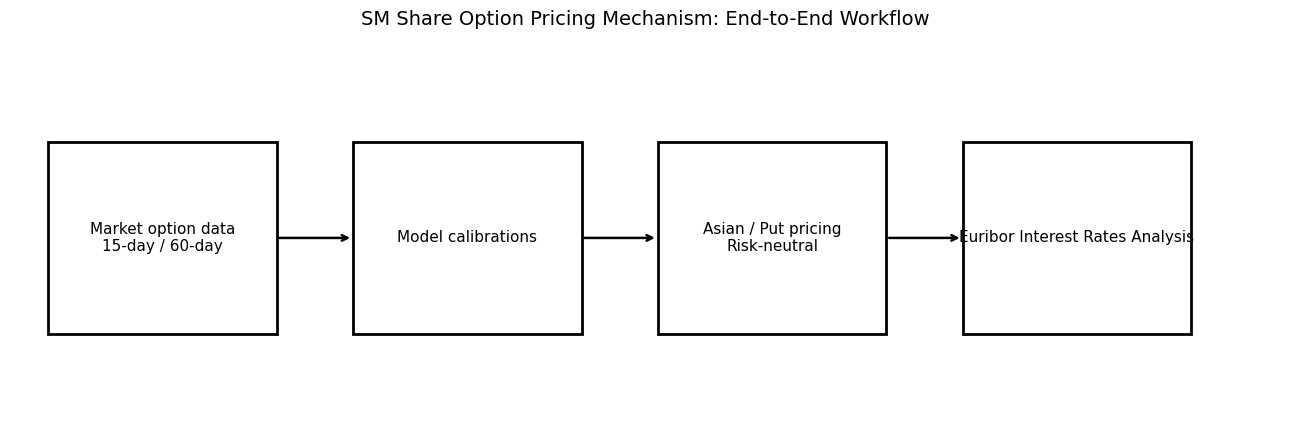

In [1]:
# Figure 0 — Project workflow diagram for the final PDF.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axis("off")

boxes = [
    (0.03, 0.35, 0.18, 0.30, "Market option data\n15-day / 60-day"),
    (0.27, 0.35, 0.18, 0.30, "Model calibrations"),
    (0.51, 0.35, 0.18, 0.30, "Asian / Put pricing\nRisk-neutral"),
    (0.75, 0.35, 0.18, 0.30, "Euribor Interest Rates Analysis")
]

for x, y, w, h, label in boxes:
    rect = plt.Rectangle(
        (x, y), w, h,
        fill=False,
        linewidth=2
    )
    ax.add_patch(rect)
    ax.text(
        x+w/2, y+h/2,
        label,
        ha="center",
        va="center",
        fontsize=11
    )

for start, end in [
    ((0.21, 0.50), (0.27, 0.50)),
    ((0.45, 0.50), (0.51, 0.50)),
    ((0.69, 0.50), (0.75, 0.50))
]:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", linewidth=1.8)
    )

ax.set_xlim(0, 1)
ax.set_ylim(0.2, 0.8)
ax.set_title("SM Share Option Pricing Mechanism: End-to-End Workflow", fontsize=14, pad=15)

plt.tight_layout()
plt.show()


In [2]:
# Install/check the packages used by the notebook.

import sys
import numpy as np
import pandas as pd

from scipy.integrate import quad
from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import CubicSpline
from scipy.fft import fft, ifft
from scipy.stats import norm


### 2.1
The model calculations are performed under the risk-neutral measure with a constant annual short rate of 1.50%. Maturities are converted from trading days using 250 trading days per year, exactly as specified in the project.


In [3]:
# Global project constants

S0 = 232.90
r = 0.015
TRADING_DAYS = 250

T_15 = 15 / TRADING_DAYS
T_20 = 20 / TRADING_DAYS
T_60 = 60 / TRADING_DAYS
T_70 = 70 / TRADING_DAYS

K_ASIAN = S0
K_PUT = 0.95 * S0

print(f"S0 = ${S0:.2f}")
print(f"Risk-free rate = {r:.2%}")
print(f"15-day T = {T_15:.6f} years")
print(f"20-day T = {T_20:.6f} years")
print(f"60-day T = {T_60:.6f} years")
print(f"70-day T = {T_70:.6f} years")
print(f"ATM Asian strike = ${K_ASIAN:.2f}")
print(f"95% moneyness put strike = ${K_PUT:.2f}")


S0 = $232.90
Risk-free rate = 1.50%
15-day T = 0.060000 years
20-day T = 0.080000 years
60-day T = 0.240000 years
70-day T = 0.280000 years
ATM Asian strike = $232.90
95% moneyness put strike = $221.25


## 3. Data importation


In [4]:
# Data needed for the assignment

SHEET_ID = "1YNqTHLMxoGpyehXfpNg7WMbDSdnYQPwR"
GOOGLE_XLSX_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=xlsx"

print("Google Sheet export URL prepared.")
print(GOOGLE_XLSX_URL)


Google Sheet export URL prepared.
https://docs.google.com/spreadsheets/d/1YNqTHLMxoGpyehXfpNg7WMbDSdnYQPwR/export?format=xlsx


In [5]:
# Dataset inspection.

options_raw = pd.read_excel(GOOGLE_XLSX_URL)

print("sum of mising values:", options_raw.isnull().sum())
print("Shape:", options_raw.shape)
print("Columns:", list(options_raw.columns))


sum of mising values: Days to maturity    0
Strike              0
Price               0
Type                0
dtype: int64
Shape: (30, 4)
Columns: ['Days to maturity', 'Strike', 'Price', 'Type']


### 3.1 Standardized columns
- `Days` — days to maturity
- `Strike` — strike price
- `Price` — observed option price
- `Type` — `C` or `P`

No market observations are changed; only column labels are standardized.


In [6]:
# Normalize column names without changing the underlying observations.

options = options_raw.copy()

options = options.rename(columns={
    "Days to maturity": "Days",
    "Strike": "Strike",
    "Price": "Price",
    "Type": "Type"
})

options["Type"] = (
    options["Type"]
    .astype(str)
    .str.upper()
    .str.strip()
    .replace({"CALL": "C", "PUT": "P"})
)

options = options.dropna(
    subset=["Days", "Strike", "Price", "Type"]
)

display(options.head())

print("\nCounts by maturity and type:")
display(pd.crosstab(options["Days"], options["Type"]))


,Days,Strike,Price,Type
0,15,227.5,10.52,C
1,15,230.0,10.05,C
2,15,232.5,7.75,C
3,15,235.0,6.01,C
4,15,237.5,4.75,C



Counts by maturity and type:


Type,C,P
Days,,
15,5,5
60,5,5
120,5,5


In [7]:
# Extract the 15-day & 30-day maturities.

options_15 = options.loc[options["Days"] == 15].copy()
options_60 = options.loc[options["Days"] == 60].copy()

if options_15.empty:
    raise ValueError("No 15-day observations were found in the option dataset.")

if options_60.empty:
    raise ValueError("No 60-day observations were found in the option dataset.")

print(f"15-day contracts: {len(options_15)}")
print(f"60-day contracts: {len(options_60)}")

display(options_15.sort_values(["Type", "Strike"]))
display(options_60.sort_values(["Type", "Strike"]))


15-day contracts: 10
60-day contracts: 10


,Days,Strike,Price,Type
0,15,227.5,10.52,C
1,15,230.0,10.05,C
2,15,232.5,7.75,C
3,15,235.0,6.01,C
4,15,237.5,4.75,C
15,15,227.5,4.32,P
16,15,230.0,5.20,P
17,15,232.5,6.45,P
18,15,235.0,7.56,P
19,15,237.5,8.78,P


,Days,Strike,Price,Type
5,60,227.5,16.78,C
6,60,230.0,17.65,C
7,60,232.5,16.86,C
8,60,235.0,16.05,C
9,60,237.5,15.10,C
20,60,227.5,11.03,P
21,60,230.0,12.15,P
22,60,232.5,13.37,P
23,60,235.0,14.75,P
24,60,237.5,15.62,P


## 4. Heston model

Under the risk-neutral measure, the Heston parameters are:

- (v_0): initial variance
- (kappa): variance mean-reversion speed
- (theta): long-run variance
- (sigma): volatility of variance
- (rho): spot/variance correlation



In [8]:
# Heston characteristic function for the log-return log(S_T / S_0).

def heston_cf_return(u, T, v0, kappa, theta, sigma, rho):
    i = 1j
    d = np.sqrt(
        (kappa - rho*sigma*i*u)**2
        + sigma**2*(u**2 + i*u)
    )
    d = np.where(np.real(d) < 0, -d, d)

    g = (
        kappa-rho*sigma*i*u-d
    ) / (
        kappa-rho*sigma*i*u+d
    )

    C = (
        i*u*r*T
        + (kappa*theta/sigma**2)
        * (
            (kappa-rho*sigma*i*u-d)*T
            - 2*np.log(
                (1-g*np.exp(-d*T))/(1-g)
            )
        )
    )

    D = (
        (kappa-rho*sigma*i*u-d)
        / sigma**2
        * (1-np.exp(-d*T))
        / (1-g*np.exp(-d*T))
    )

    return np.exp(C+D*v0)


## 5. Lewis (2001) pricing

Lewis (2001) expresses the option value as a Fourier-space integral. This is particularly useful here because the Heston and Bates models have analytical characteristic functions.

Lewis's paper develops the Fourier inversion approach used here.


In [9]:
def heston_call_lewis(K, T, params, u_max=100):
    v0, kappa, theta, sigma, rho = params
    log_moneyness = np.log(S0/K)

    def integrand(u):
        phi = heston_cf_return(
            u-0.5j, T,
            v0, kappa, theta, sigma, rho
        )
        return np.real(
            np.exp(1j*u*log_moneyness)
            * phi/(u**2+0.25)
        )

    integral = quad(
        integrand, 0, u_max,
        limit=200,
        epsabs=1e-7,
        epsrel=1e-7
    )[0]

    return (
        S0
        - np.exp(-r*T)*np.sqrt(S0*K)/np.pi*integral
    )


def heston_put_parity(K, T, params):
    call = heston_call_lewis(K, T, params)
    return call-S0+K*np.exp(-r*T)


In [10]:
# Quick pricing sanity check at the 15-day ATM strike.

atm_15 = options_15.iloc[
    (options_15["Strike"] - S0).abs().argsort()[:1]
]

print("Closest 15-day strike to spot:")
display(atm_15)


Closest 15-day strike to spot:


,Days,Strike,Price,Type
2,15,232.5,7.75,C


## 6. Heston calibration — Step 1(a)

The calibration target is the observed **15-day** call and put prices. The objective is the regular mean squared pricing error.

In [11]:
# MSE objective for Heston/Lewis.

def heston_mse(params, data):
    v0, kappa, theta, sigma, rho = params

    # Basic admissibility constraints.
    if (
        v0 <= 0
        or kappa <= 0
        or theta <= 0
        or sigma <= 0
        or abs(rho) >= 1
    ):
        return 1e10

    errors = []

    for row in data.itertuples(index=False):
        if row.Type == "C":
            model = heston_call_lewis(
                row.Strike, T_15, params
            )
        else:
            model = heston_put_parity(
                row.Strike, T_15, params
            )

        errors.append(model - row.Price)

    return np.mean(np.square(errors))


HESTON_BOUNDS = [
    (1e-5, 1.0),     # v0
    (0.05, 10.0),    # kappa
    (1e-5, 1.0),     # theta
    (0.05, 3.0),    # sigma
    (-0.999, 0.999)  # rho
]


In [12]:
# Multi-start Heston calibration. This reduces the risk of reporting a local optimum from one arbitrary starting point.

heston_starts = [
    [0.04, 1.5, 0.04, 0.30, -0.70],
    [0.09, 2.0, 0.06, 0.40, -0.50],
    [0.16, 3.0, 0.08, 0.60, -0.30],
    [0.06, 5.0, 0.05, 0.25, -0.80],
]

heston_results = []

for x0 in heston_starts:
    result = minimize(
        heston_mse,
        x0=x0,
        args=(options_15,),
        method="L-BFGS-B",
        bounds=HESTON_BOUNDS,
        options={"maxiter": 300, "ftol": 1e-10}
    )

    heston_results.append(result)

best_heston = min(heston_results, key=lambda x: x.fun)
heston_params = best_heston.x

print("Best Heston calibration:")
print("v0    =", heston_params[0])
print("kappa =", heston_params[1])
print("theta =", heston_params[2])
print("sigma =", heston_params[3])
print("rho   =", heston_params[4])
print("MSE   =", best_heston.fun)
print("Success:", best_heston.success)
print("Message:", best_heston.message)


Best Heston calibration:
v0    = 0.10751562759513233
kappa = 1.4934408936607733
theta = 1e-05
sigma = 1.3555860275170692
rho   = -0.8711905328561173
MSE   = 0.246153707792324
Success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [13]:
# Heston parameter table and Feller diagnostic.

v0_h, kappa_h, theta_h, sigma_h, rho_h = heston_params

feller_lhs_h = 2 * kappa_h * theta_h
feller_rhs_h = sigma_h**2

heston_table = pd.DataFrame({
    "Parameter": ["v0", "kappa", "theta", "sigma", "rho"],
    "Estimate": heston_params
})

display(heston_table)

print(f"Feller LHS = 2*kappa*theta = {feller_lhs_h:.6f}")
print(f"Feller RHS = sigma^2       = {feller_rhs_h:.6f}")
print("Feller condition satisfied:", feller_lhs_h > feller_rhs_h)


,Parameter,Estimate
0,v0,0.107516
1,kappa,1.493441
2,theta,0.000010
3,sigma,1.355586
4,rho,-0.871191


Feller LHS = 2*kappa*theta = 0.000030
Feller RHS = sigma^2       = 1.837613
Feller condition satisfied: False


In [14]:
# Heston calibration diagnostics.

def heston_model_prices(data, params):
    model_prices = []

    for row in data.itertuples(index=False):
        if row.Type == "C":
            model = heston_call_lewis(row.Strike, T_15, params)
        else:
            model = heston_put_parity(row.Strike, T_15, params)

        model_prices.append(model)

    out = data.copy()
    out["Model Price"] = model_prices
    out["Error"] = out["Model Price"] - out["Price"]
    out["Absolute Error"] = out["Error"].abs()
    return out

heston_fit = heston_model_prices(options_15, heston_params)

print("Heston fit statistics:")
display(
    heston_fit[["Type", "Strike", "Price", "Model Price", "Error", "Absolute Error"]]
)

print("MSE =", np.mean(heston_fit["Error"]**2))
print("RMSE =", np.sqrt(np.mean(heston_fit["Error"]**2)))


Heston fit statistics:


,Type,Strike,Price,Model Price,Error,Absolute Error
0,C,227.5,10.52,10.514896,-0.005104,0.005104
1,C,230.0,10.05,8.858398,-1.191602,1.191602
2,C,232.5,7.75,7.319301,-0.430699,0.430699
3,C,235.0,6.01,5.906522,-0.103478,0.103478
4,C,237.5,4.75,4.628469,-0.121531,0.121531
15,P,227.5,4.32,4.910238,0.590238,0.590238
16,P,230.0,5.20,5.751491,0.551491,0.551491
17,P,232.5,6.45,6.710145,0.260145,0.260145
18,P,235.0,7.56,7.795117,0.235117,0.235117
19,P,237.5,8.78,9.014815,0.234815,0.234815


MSE = 0.246153707792324
RMSE = 0.49613879891853246


### Heston calibration interpretation

The calibration selects the parameter vector that minimizes the squared difference between the model prices and observed 15-day market prices. The parameter table and fit table should be retained in the final report because they provide the quantitative evidence supporting the calibration.

The fit graph below is more informative than the MSE alone: a good calibration should place the model prices close to the market observations across both calls and puts and should not show a systematic pattern in the residuals.


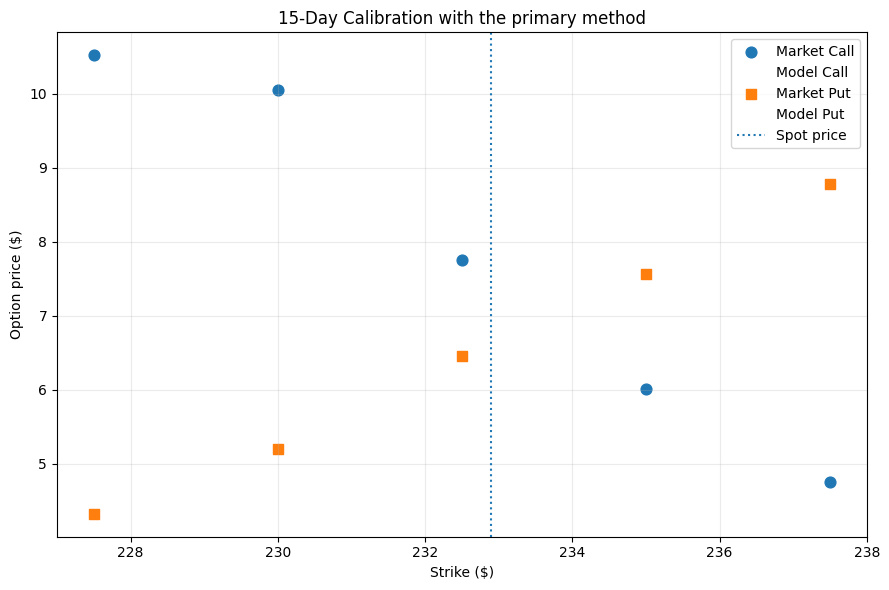

In [15]:
# Figure 1 — Heston 15-day market versus model prices.

fig, ax = plt.subplots(figsize=(9, 6))

for opt_type, marker in [("C", "o"), ("P", "s")]:
    subset = heston_fit[heston_fit["Type"] == opt_type]

    ax.scatter(
        subset["Strike"],
        subset["Price"],
        marker=marker,
        s=60,
        label=f"Market {'Call' if opt_type == 'C' else 'Put'}"
    )

    ax.scatter(
        subset["Strike"],
        subset["Model Price"],
        marker=marker,
        s=120,
        facecolors="none",
        label=f"Model {'Call' if opt_type == 'C' else 'Put'}"
    )

ax.axvline(S0, linestyle=":", label="Spot price")
ax.set_title("15-Day Calibration with the primary method")
ax.set_xlabel("Strike ($)")
ax.set_ylabel("Option price ($)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


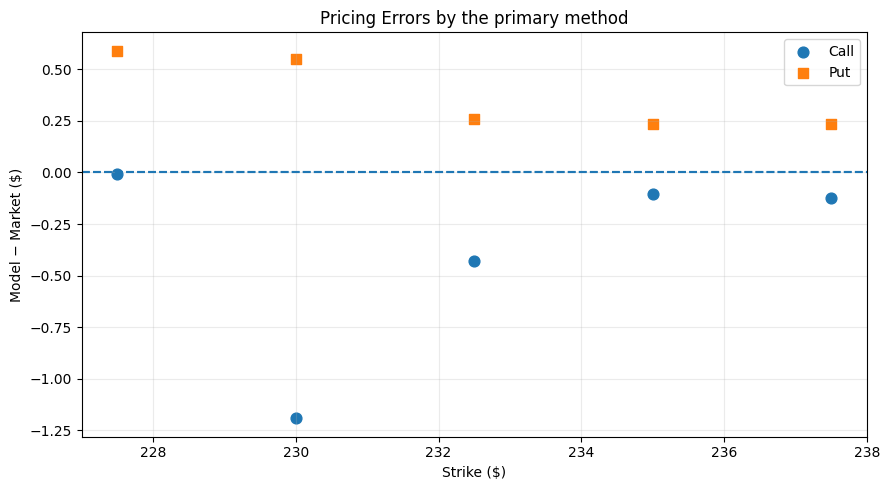

In [16]:
# Figure 2 — Heston residuals.

fig, ax = plt.subplots(figsize=(9, 5))

for opt_type, marker in [("C", "o"), ("P", "s")]:
    subset = heston_fit[heston_fit["Type"] == opt_type]
    ax.axhline(0, linestyle="--")
    ax.scatter(
        subset["Strike"],
        subset["Error"],
        marker=marker,
        s=60,
        label=f"{'Call' if opt_type == 'C' else 'Put'}"
    )

ax.set_title("Pricing Errors by the primary method")
ax.set_xlabel("Strike ($)")
ax.set_ylabel("Model − Market ($)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 7. Step 1(b) — Heston with Carr–Madan FFT

Carr and Madan (1999) show how the Fast Fourier Transform can be used to value options when the return characteristic function is known analytically.

This section deliberately uses the **same 15-day data and the same Heston model**, changing only the numerical pricing method. This makes the comparison between Lewis and Carr–Madan meaningful.


In [17]:
# Carr-Madan FFT grid and pricing routine.

def carr_madan_call_grid(
    T, params, alpha=1.5, N=4096, eta=0.05
):
    v0, kappa, theta, sigma, rho = params
    i = 1j
    u = np.arange(N)*eta
    u_shift = u-(alpha+1)*i

    phi_return = heston_cf_return(
        u_shift, T,
        v0, kappa, theta, sigma, rho
    )

    phi_abs = phi_return*np.exp(
        i*u_shift*np.log(S0)
    )

    denominator = (
        alpha**2+alpha-u**2
        + i*(2*alpha+1)*u
    )

    psi = np.exp(-r*T)*phi_abs/denominator

    weights = np.ones(N)
    weights[0] = 1/3
    weights[1:-1:2] = 4/3
    weights[2:-1:2] = 2/3

    b = np.pi/eta
    logK_min = np.log(S0)-b

    k_grid = (
        logK_min
        + np.arange(N)*2*np.pi/(N*eta)
    )

    fft_input = (
        np.exp(-1j*u*logK_min)
        * psi*weights*eta
    )

    fft_output = fft(fft_input)

    calls = (
        np.exp(-alpha*k_grid)
        / np.pi*np.real(fft_output)
    )

    return np.exp(k_grid), np.maximum(calls,0)


In [18]:
# Interpolate the FFT call curve at observed strikes.

def heston_call_carr_madan(K, T, params):
    strikes, calls = carr_madan_call_grid(T, params)
    return float(np.interp(K, strikes, calls))


def heston_put_carr_madan(K, T, params):
    call = heston_call_carr_madan(K, T, params)
    return call - S0 + K*np.exp(-r*T)


In [19]:
# Sanity-check Carr-Madan against Lewis at the observed strikes.

comparison = []

for row in options_15.itertuples(index=False):
    if row.Type == "C":
        lewis = heston_call_lewis(row.Strike, T_15, heston_params)
        cm = heston_call_carr_madan(row.Strike, T_15, heston_params)
    else:
        lewis = heston_put_parity(row.Strike, T_15, heston_params)
        cm = heston_put_carr_madan(row.Strike, T_15, heston_params)

    comparison.append({
        "Type": row.Type,
        "Strike": row.Strike,
        "Lewis": lewis,
        "Carr-Madan": cm,
        "Difference": cm - lewis
    })

cm_check = pd.DataFrame(comparison)
display(cm_check)

print("Maximum absolute Lewis/Carr-Madan difference:",
      cm_check["Difference"].abs().max())


,Type,Strike,Lewis,Carr-Madan,Difference
0,C,227.5,10.514896,10.594178,0.079283
1,C,230.0,8.858398,8.969160,0.110762
2,C,232.5,7.319301,7.344142,0.024841
3,C,235.0,5.906522,6.026885,0.120363
4,C,237.5,4.628469,4.768249,0.139780
5,P,227.5,4.910238,4.989520,0.079283
6,P,230.0,5.751491,5.862253,0.110762
7,P,232.5,6.710145,6.734986,0.024841
8,P,235.0,7.795117,7.915480,0.120363
9,P,237.5,9.014815,9.154595,0.139780


Maximum absolute Lewis/Carr-Madan difference: 0.1397798604910463


### Carr–Madan calibration
The Heston parameters are re-estimated by minimizing the same MSE objective, but replacing the Lewis pricing engine with the Carr–Madan FFT engine. In an adequately resolved FFT grid, the two calibrations should be reasonably close because they are pricing the same model against the same observations; differences arise from numerical integration/FFT discretization and optimization.


In [20]:
def heston_mse_carr_madan(params, data):
    v0, kappa, theta, sigma, rho = params

    if (
        v0 <= 0
        or kappa <= 0
        or theta <= 0
        or sigma <= 0
        or abs(rho) >= 1
    ):
        return 1e10

    errors = []

    for row in data.itertuples(index=False):
        if row.Type == "C":
            model = heston_call_carr_madan(row.Strike, T_15, params)
        else:
            model = heston_put_carr_madan(row.Strike, T_15, params)

        errors.append(model - row.Price)

    return np.mean(np.square(errors))


In [21]:
# Member B: multi-start Carr-Madan calibration.

cm_results = []

for x0 in heston_starts:
    result = minimize(
        heston_mse_carr_madan,
        x0=x0,
        args=(options_15,),
        method="L-BFGS-B",
        bounds=HESTON_BOUNDS,
        options={"maxiter": 100, "ftol": 1e-8}
    )

    cm_results.append(result)

best_cm = min(cm_results, key=lambda x: x.fun)
heston_cm_params = best_cm.x

cm_parameter_table = pd.DataFrame({
    "Parameter": ["v0", "kappa", "theta", "sigma", "rho"],
    "Lewis": heston_params,
    "Carr-Madan": heston_cm_params
})

display(cm_parameter_table)

print("Lewis MSE:", best_heston.fun)
print("Carr-Madan MSE:", best_cm.fun)
print("Carr-Madan optimizer success:", best_cm.success)


,Parameter,Lewis,Carr-Madan
0,v0,0.107516,0.103386
1,kappa,1.493441,1.494735
2,theta,0.000010,0.000010
3,sigma,1.355586,1.262100
4,rho,-0.871191,-0.999000


Lewis MSE: 0.246153707792324
Carr-Madan MSE: 0.2474590184968363
Carr-Madan optimizer success: True


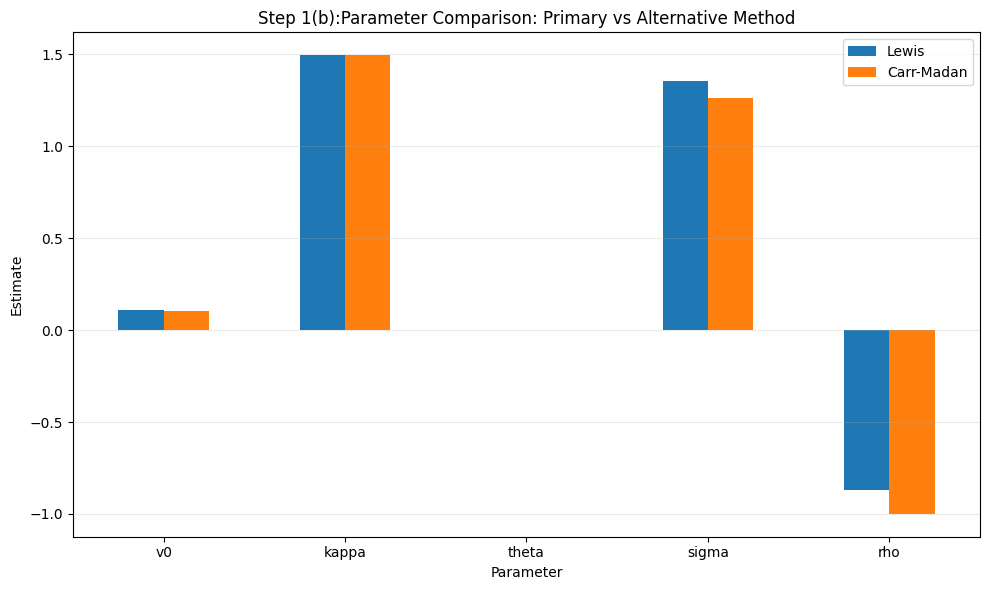

In [22]:
# Figure 3 — Lewis versus Carr-Madan parameter estimates.

plot_df = cm_parameter_table.set_index("Parameter")

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Step 1(b):Parameter Comparison: Primary vs Alternative Method")
ax.set_xlabel("Parameter")
ax.set_ylabel("Estimate")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## 8. Step 1(c) — 20-day ATM Asian call

The client wants an ATM Asian call with 20 days to maturity.

Monte Carlo is required because the payoff depends on the entire simulated price path rather than only the terminal price.


In [23]:
# Risk-neutral Heston Monte Carlo for the Asian call.

def mc_heston_asian(
    params,
    maturity_days=20,
    n_paths=100_000,
    seed=2026,
    antithetic=True
):
    v0, kappa, theta, sigma, rho = params

    n_steps = maturity_days
    dt = 1 / TRADING_DAYS

    rng = np.random.default_rng(seed)

    S = np.full(n_paths, S0, dtype=float)
    v = np.full(n_paths, v0, dtype=float)

    # Today's price S0 is included in the arithmetic average.
    path_sum = S.copy()

    for _ in range(n_steps):
        if antithetic:
            n_base = (n_paths + 1) // 2
            z1_base = rng.standard_normal(n_base)
            z2_base = rng.standard_normal(n_base)

            z1 = np.concatenate([z1_base, -z1_base])[:n_paths]
            z2 = np.concatenate([z2_base, -z2_base])[:n_paths]
        else:
            z1 = rng.standard_normal(n_paths)
            z2 = rng.standard_normal(n_paths)

        z_v = rho*z1 + np.sqrt(1-rho**2)*z2

        v_pos = np.maximum(v, 0)

        S = S * np.exp(
            (r - 0.5*v_pos)*dt
            + np.sqrt(v_pos*dt)*z1
        )

        v = (
            v
            + kappa*(theta-v_pos)*dt
            + sigma*np.sqrt(v_pos*dt)*z_v
        )

        v = np.maximum(v, 0)

        path_sum += S

    average_S = path_sum / (maturity_days + 1)

    payoff = np.maximum(
        average_S - K_ASIAN,
        0
    )

    discounted = np.exp(-r*T_20) * payoff

    price = discounted.mean()
    standard_error = discounted.std(ddof=1) / np.sqrt(n_paths)

    return price, standard_error, discounted


In [24]:
asian_fair, asian_se, asian_discounted_payoffs = mc_heston_asian(
    heston_params,
    maturity_days=20,
    n_paths=100_000,
    seed=2026
)

asian_ci95 = 1.96 * asian_se
asian_fee = 0.04 * asian_fair
asian_client_price = asian_fair + asian_fee

asian_summary = pd.DataFrame({
    "Measure": [
        "Fair value",
        "Monte Carlo standard error",
        "95% half-width",
        "4% bank fee",
        "Client price"
    ],
    "Value": [
        asian_fair,
        asian_se,
        asian_ci95,
        asian_fee,
        asian_client_price
    ]
})

display(asian_summary)

print(
    f"95% Monte Carlo interval: "
    f"[{asian_fair-asian_ci95:.4f}, {asian_fair+asian_ci95:.4f}]"
)


,Measure,Value
0,Fair value,4.826362
1,Monte Carlo standard error,0.018635
2,95% half-width,0.036525
3,4% bank fee,0.193054
4,Client price,5.019417


95% Monte Carlo interval: [4.7898, 4.8629]


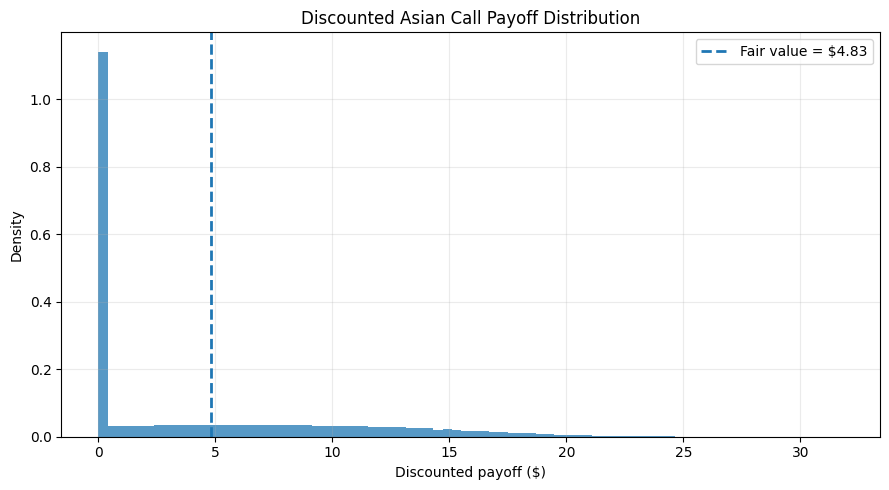

In [25]:
# Figure 4 — Distribution of simulated discounted Asian payoffs.

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    asian_discounted_payoffs,
    bins=80,
    density=True,
    alpha=0.75
)

ax.axvline(
    asian_fair,
    linestyle="--",
    linewidth=2,
    label=f"Fair value = ${asian_fair:.2f}"
)

ax.set_title("Discounted Asian Call Payoff Distribution")
ax.set_xlabel("Discounted payoff ($)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 9. Bates model

The Bates model extends Heston by adding a jump component. The jump size is assumed lognormally distributed:

The jump component is risk-neutralized by subtracting its expected jump contribution from the stock drift. Bates (1996) develops the stochastic-volatility/jump-diffusion framework.


In [26]:
# Bates characteristic function for the log-return log(S_T / S_0).

def bates_cf_return(
    u, T,
    v0, kappa, theta, sigma, rho,
    lam, muJ, sigmaJ
):
    i = 1j

    d = np.sqrt(
        (kappa-rho*sigma*i*u)**2
        + sigma**2*(u**2+i*u)
    )
    d = np.where(np.real(d)<0,-d,d)

    g = (
        kappa-rho*sigma*i*u-d
    ) / (
        kappa-rho*sigma*i*u+d
    )

    C_h = (
        i*u*r*T
        + (kappa*theta/sigma**2)
        * (
            (kappa-rho*sigma*i*u-d)*T
            - 2*np.log(
                (1-g*np.exp(-d*T))/(1-g)
            )
        )
    )

    D_h = (
        (kappa-rho*sigma*i*u-d)/sigma**2
        * (1-np.exp(-d*T))
        / (1-g*np.exp(-d*T))
    )

    jump_mean = np.exp(
        muJ+0.5*sigmaJ**2
    )-1

    C_jump = (
        lam*T
        * (
            np.exp(
                i*u*muJ
                - 0.5*sigmaJ**2*u**2
            )
            - 1-i*u*jump_mean
        )
    )

    return np.exp(
        C_h+D_h*v0+C_jump
    )


In [27]:
# Lewis pricing for Bates using the return characteristic function.

def bates_call_lewis(K, T, params, u_max=100):
    (
        v0,kappa,theta,sigma,rho,
        lam,muJ,sigmaJ
    ) = params

    log_moneyness = np.log(S0/K)

    def integrand(u):
        phi = bates_cf_return(
            u-0.5j,T,
            v0,kappa,theta,sigma,rho,
            lam,muJ,sigmaJ
        )
        return np.real(
            np.exp(1j*u*log_moneyness)
            * phi/(u**2+0.25)
        )

    integral = quad(
        integrand,0,u_max,
        limit=200,
        epsabs=1e-7,
        epsrel=1e-7
    )[0]

    return (
        S0
        - np.exp(-r*T)*np.sqrt(S0*K)/np.pi*integral
    )


def bates_put_parity(K,T,params):
    call=bates_call_lewis(K,T,params)
    return call-S0+K*np.exp(-r*T)


## 10. Step 2(a) — Bates/Lewis calibration at 60 days
As with Heston, the objective is regular MSE.


In [28]:
# Bates MSE objective.

def bates_mse(params, data):
    (
        v0, kappa, theta, sigma, rho,
        lam, muJ, sigmaJ
    ) = params

    if (
        v0 <= 0
        or kappa <= 0
        or theta <= 0
        or sigma <= 0
        or abs(rho) >= 1
        or lam < 0
        or sigmaJ < 0
    ):
        return 1e10

    errors = []

    for row in data.itertuples(index=False):
        if row.Type == "C":
            model = bates_call_lewis(
                row.Strike,
                T_60,
                params
            )
        else:
            model = bates_put_parity(
                row.Strike,
                T_60,
                params
            )

        errors.append(model - row.Price)

    return np.mean(np.square(errors))


BATES_BOUNDS = [
    (1e-5, 1.0),      # v0
    (0.05, 10.0),     # kappa
    (1e-5, 1.0),      # theta
    (0.05, 3.0),      # sigma
    (-0.999, 0.999),  # rho
    (0.0, 5.0),       # lambda
    (-0.75, 0.75),    # muJ
    (1e-4, 0.75)      # sigmaJ
]


In [29]:
# Multiple admissible Bates starting points.

bates_starts = [
    [0.04, 1.5, 0.04, 0.30, -0.70, 0.25, -0.05, 0.10],
    [0.09, 2.0, 0.06, 0.40, -0.50, 0.50, -0.10, 0.15],
    [0.16, 3.0, 0.08, 0.60, -0.30, 1.00, -0.15, 0.20],
    [0.06, 5.0, 0.05, 0.25, -0.80, 0.10, 0.05, 0.08]
]

bates_results = []

for x0 in bates_starts:
    result = minimize(
        bates_mse,
        x0=x0,
        args=(options_60,),
        method="L-BFGS-B",
        bounds=BATES_BOUNDS,
        options={"maxiter": 250, "ftol": 1e-8}
    )

    bates_results.append(result)

best_bates = min(bates_results, key=lambda x: x.fun)
bates_params = best_bates.x

bates_names = [
    "v0", "kappa", "theta", "sigma",
    "rho", "lambda", "muJ", "sigmaJ"
]

bates_parameter_table = pd.DataFrame({
    "Parameter": bates_names,
    "Estimate": bates_params
})

display(bates_parameter_table)

print("Bates MSE:", best_bates.fun)
print("Optimizer success:", best_bates.success)
print("Optimizer message:", best_bates.message)


,Parameter,Estimate
0,v0,0.000010
1,kappa,1.870666
2,theta,0.000010
3,sigma,3.000000
4,rho,-0.373029
5,lambda,1.937029
6,muJ,0.210434
7,sigmaJ,0.000100


Bates MSE: 1.3226076081349434
Optimizer success: True
Optimizer message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [30]:
# Bates fit diagnostics.

def bates_model_prices(data, params):
    out = data.copy()
    model_prices = []

    for row in data.itertuples(index=False):
        if row.Type == "C":
            model = bates_call_lewis(row.Strike, T_60, params)
        else:
            model = bates_put_parity(row.Strike, T_60, params)

        model_prices.append(model)

    out["Model Price"] = model_prices
    out["Error"] = out["Model Price"] - out["Price"]
    out["Absolute Error"] = out["Error"].abs()

    return out


bates_fit = bates_model_prices(
    options_60,
    bates_params
)

display(
    bates_fit[
        ["Type", "Strike", "Price", "Model Price", "Error", "Absolute Error"]
    ]
)

print("Bates MSE:",
      np.mean(bates_fit["Error"]**2))
print("Bates RMSE:",
      np.sqrt(np.mean(bates_fit["Error"]**2)))


,Type,Strike,Price,Model Price,Error,Absolute Error
5,C,227.5,16.78,17.352126,0.572126,0.572126
6,C,230.0,17.65,16.477821,-1.172179,1.172179
7,C,232.5,16.86,15.599213,-1.260787,1.260787
8,C,235.0,16.05,14.664945,-1.385055,1.385055
9,C,237.5,15.10,13.688638,-1.411362,1.411362
20,P,227.5,11.03,11.134598,0.104598,0.104598
21,P,230.0,12.15,12.751310,0.601310,0.601310
22,P,232.5,13.37,14.363717,0.993717,0.993717
23,P,235.0,14.75,15.920466,1.170466,1.170466
24,P,237.5,15.62,17.435175,1.815175,1.815175


Bates MSE: 1.3226076081349434
Bates RMSE: 1.1500467851939518


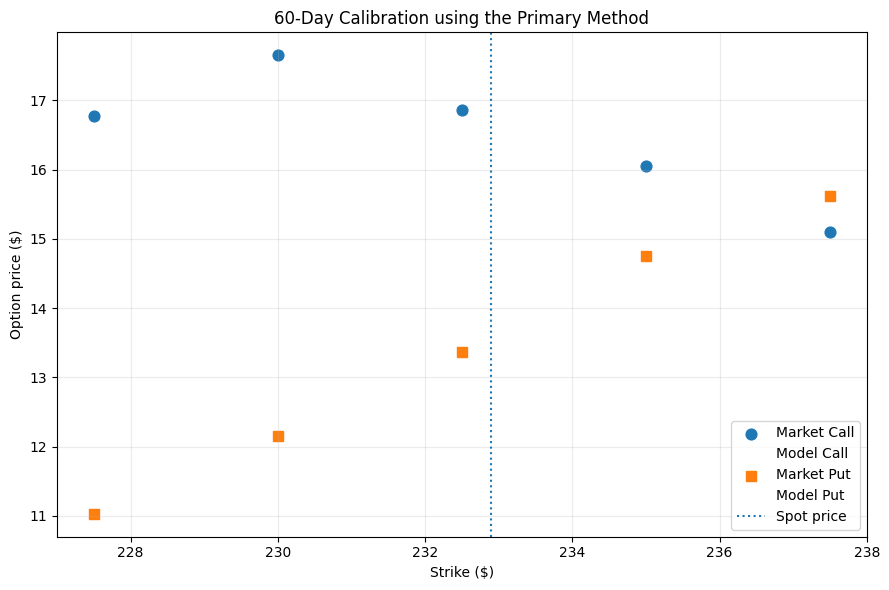

In [31]:
# Bates 60-day market versus model prices.

fig, ax = plt.subplots(figsize=(9, 6))

for opt_type, marker in [("C", "o"), ("P", "s")]:
    subset = bates_fit[bates_fit["Type"] == opt_type]

    ax.scatter(
        subset["Strike"],
        subset["Price"],
        marker=marker,
        s=60,
        label=f"Market {'Call' if opt_type == 'C' else 'Put'}"
    )

    ax.scatter(
        subset["Strike"],
        subset["Model Price"],
        marker=marker,
        s=60,
        facecolors="none",
        label=f"Model {'Call' if opt_type == 'C' else 'Put'}"
    )

ax.axvline(S0, linestyle=":", label="Spot price")
ax.set_title("60-Day Calibration using the Primary Method")
ax.set_xlabel("Strike ($)")
ax.set_ylabel("Option price ($)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 11. Step 2(b) — Member A: Bates with Carr–Madan

The same Bates characteristic function is now used in a Carr–Madan FFT pricing engine. The purpose is to provide an independent numerical check of the 60-day Bates calibration.

The comparison should focus on:
- parameter estimates;
- MSE/RMSE;
- market-versus-model fit;
- whether differences are small enough to be explained by numerical integration/FFT settings.

Carr and Madan's method is based on Fourier transformation of a damped option-price function.

In [32]:
def carr_madan_bates_call_grid(
    T, params, alpha=1.5, N=4096, eta=0.05
):
    (
        v0,kappa,theta,sigma,rho,
        lam,muJ,sigmaJ
    ) = params

    i=1j
    u=np.arange(N)*eta
    u_shift=u-(alpha+1)*i

    phi_return=bates_cf_return(
        u_shift,T,
        v0,kappa,theta,sigma,rho,
        lam,muJ,sigmaJ
    )

    phi_abs=phi_return*np.exp(
        i*u_shift*np.log(S0)
    )

    denominator=(
        alpha**2+alpha-u**2
        + i*(2*alpha+1)*u
    )

    psi=np.exp(-r*T)*phi_abs/denominator

    weights=np.ones(N)
    weights[0]=1/3
    weights[1:-1:2]=4/3
    weights[2:-1:2]=2/3

    b=np.pi/eta
    logK_min=np.log(S0)-b

    k_grid=(
        logK_min
        + np.arange(N)*2*np.pi/(N*eta)
    )

    fft_input=(
        np.exp(-1j*u*logK_min)
        * psi*weights*eta
    )

    fft_output=fft(fft_input)

    calls=(
        np.exp(-alpha*k_grid)
        / np.pi*np.real(fft_output)
    )

    return np.exp(k_grid),np.maximum(calls,0)


def bates_call_carr_madan(K,T,params):
    strikes,calls=carr_madan_bates_call_grid(T,params)
    return float(np.interp(K,strikes,calls))


def bates_put_carr_madan(K,T,params):
    call=bates_call_carr_madan(K,T,params)
    return call-S0+K*np.exp(-r*T)


In [33]:
# Carr-Madan sanity check for the calibrated Bates parameters.

bates_cm_check = []

for row in options_60.itertuples(index=False):
    if row.Type == "C":
        lewis = bates_call_lewis(
            row.Strike, T_60, bates_params
        )
        cm = bates_call_carr_madan(
            row.Strike, T_60, bates_params
        )
    else:
        lewis = bates_put_parity(
            row.Strike, T_60, bates_params
        )
        cm = bates_put_carr_madan(
            row.Strike, T_60, bates_params
        )

    bates_cm_check.append({
        "Type": row.Type,
        "Strike": row.Strike,
        "Lewis": lewis,
        "Carr-Madan": cm,
        "Difference": cm - lewis
    })

bates_cm_check = pd.DataFrame(bates_cm_check)
display(bates_cm_check)

print(
    "Maximum absolute Bates Lewis/Carr-Madan difference:",
    bates_cm_check["Difference"].abs().max()
)


,Type,Strike,Lewis,Carr-Madan,Difference
0,C,227.5,17.352126,17.396438,0.044313
1,C,230.0,16.477821,16.470839,-0.006982
2,C,232.5,15.599213,15.545240,-0.053973
3,C,235.0,14.664945,14.619122,-0.045823
4,C,237.5,13.688638,13.692905,0.004267
5,P,227.5,11.134598,11.178911,0.044313
6,P,230.0,12.751310,12.744328,-0.006982
7,P,232.5,14.363717,14.309745,-0.053973
8,P,235.0,15.920466,15.874643,-0.045823
9,P,237.5,17.435175,17.439443,0.004267


Maximum absolute Bates Lewis/Carr-Madan difference: 0.053972758346649385


In [34]:
def bates_mse_carr_madan(params, data):
    (
        v0, kappa, theta, sigma, rho,
        lam, muJ, sigmaJ
    ) = params

    if (
        v0 <= 0
        or kappa <= 0
        or theta <= 0
        or sigma <= 0
        or abs(rho) >= 1
        or lam < 0
        or sigmaJ < 0
    ):
        return 1e10

    errors = []

    for row in data.itertuples(index=False):
        if row.Type == "C":
            model = bates_call_carr_madan(
                row.Strike, T_60, params
            )
        else:
            model = bates_put_carr_madan(
                row.Strike, T_60, params
            )

        errors.append(model - row.Price)

    return np.mean(np.square(errors))


In [35]:
# Member A: multi-start Bates/Carr-Madan calibration.

bates_cm_results = []

for x0 in bates_starts:
    result = minimize(
        bates_mse_carr_madan,
        x0=x0,
        args=(options_60,),
        method="L-BFGS-B",
        bounds=BATES_BOUNDS,
        options={"maxiter": 100, "ftol": 1e-7}
    )

    bates_cm_results.append(result)

best_bates_cm = min(
    bates_cm_results,
    key=lambda x: x.fun
)

bates_cm_params = best_bates_cm.x

bates_comparison = pd.DataFrame({
    "Parameter": bates_names,
    "Lewis": bates_params,
    "Carr-Madan": bates_cm_params
})

display(bates_comparison)

print("Bates/Lewis MSE:", best_bates.fun)
print("Bates/Carr-Madan MSE:", best_bates_cm.fun)
print("Carr-Madan success:", best_bates_cm.success)


,Parameter,Lewis,Carr-Madan
0,v0,0.000010,0.000010
1,kappa,1.870666,3.246742
2,theta,0.000010,0.000010
3,sigma,3.000000,0.881726
4,rho,-0.373029,0.214046
5,lambda,1.937029,1.882867
6,muJ,0.210434,0.213422
7,sigmaJ,0.000100,0.000100


Bates/Lewis MSE: 1.3226076081349434
Bates/Carr-Madan MSE: 1.335035558923698
Carr-Madan success: True


## 12. Step 2(c) — Member B: 70-day European put

A 70-day put with **95% moneyness**,

The pricing process follows the same risk-neutral Monte Carlo logic used for the previous derivative-pricing task. The Bates dynamics are simulated, including the jump component and its risk-neutral drift correction.

The fair value is reported first. A 4% fee is then added, following the project's pricing instruction.


In [36]:
def mc_bates_put(
    params,
    maturity_days=70,
    strike=K_PUT,
    n_paths=100_000,
    seed=2027
):
    (
        v0, kappa, theta, sigma, rho,
        lam, muJ, sigmaJ
    ) = params

    dt = 1 / TRADING_DAYS
    rng = np.random.default_rng(seed)

    S = np.full(n_paths, S0, dtype=float)
    v = np.full(n_paths, v0, dtype=float)

    jump_drift = lam * (
        np.exp(muJ + 0.5*sigmaJ**2) - 1
    )

    for _ in range(maturity_days):

        z1 = rng.standard_normal(n_paths)
        z2 = rng.standard_normal(n_paths)

        z_v = (
            rho*z1
            + np.sqrt(1-rho**2)*z2
        )

        v_pos = np.maximum(v, 0)

        v = (
            v
            + kappa*(theta-v_pos)*dt
            + sigma*np.sqrt(v_pos*dt)*z_v
        )

        v = np.maximum(v, 0)

        S = S*np.exp(
            (r - 0.5*v_pos - jump_drift)*dt
            + np.sqrt(v_pos*dt)*z1
        )

        n_jumps = rng.poisson(
            lam*dt,
            size=n_paths
        )

        jump_paths = np.where(
            n_jumps > 0
        )[0]

        for idx in jump_paths:
            jump_sizes = rng.normal(
                muJ,
                sigmaJ,
                n_jumps[idx]
            )

            S[idx] *= np.exp(
                jump_sizes.sum()
            )

    payoff = np.maximum(
        strike-S,
        0
    )

    discounted = (
        np.exp(-r*T_70)
        * payoff
    )

    price = discounted.mean()

    se = (
        discounted.std(ddof=1)
        / np.sqrt(n_paths)
    )

    return price, se, discounted


In [37]:
put_fair, put_se, put_discounted_payoffs = mc_bates_put(
    bates_params,
    maturity_days=70,
    strike=K_PUT,
    n_paths=100_000,
    seed=2027
)

put_ci95 = 1.96 * put_se
put_fee = 0.04 * put_fair
put_client_price = put_fair + put_fee

put_summary = pd.DataFrame({
    "Measure": [
        "Strike",
        "Fair value",
        "Monte Carlo standard error",
        "95% half-width",
        "4% bank fee",
        "Client price"
    ],
    "Value": [
        K_PUT,
        put_fair,
        put_se,
        put_ci95,
        put_fee,
        put_client_price
    ]
})

display(put_summary)

print(
    f"95% Monte Carlo interval: "
    f"[{put_fair-put_ci95:.4f}, {put_fair+put_ci95:.4f}]"
)


,Measure,Value
0,Strike,221.255000
1,Fair value,9.536831
2,Monte Carlo standard error,0.039054
3,95% half-width,0.076546
4,4% bank fee,0.381473
5,Client price,9.918305


95% Monte Carlo interval: [9.4603, 9.6134]


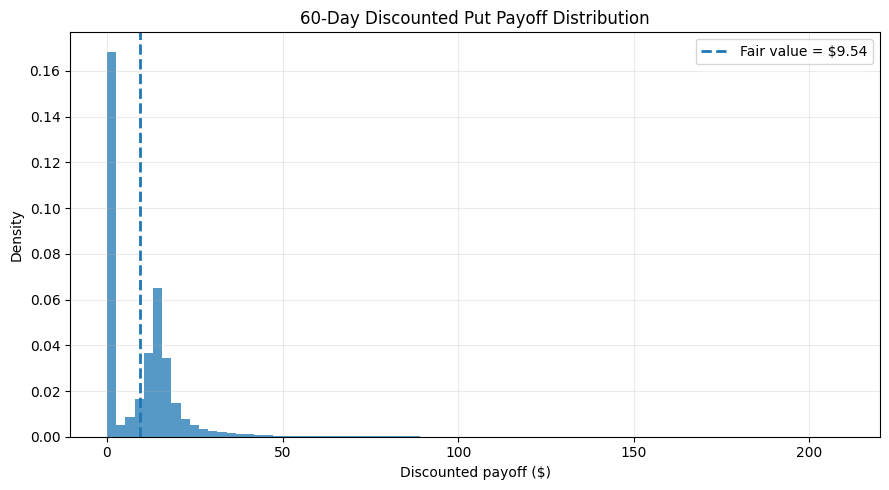

In [38]:
# Figure 6 — 70-day Bates put payoff distribution.

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    put_discounted_payoffs,
    bins=80,
    density=True,
    alpha=0.75
)

ax.axvline(
    put_fair,
    linestyle="--",
    linewidth=2,
    label=f"Fair value = ${put_fair:.2f}"
)

ax.set_title("60-Day Discounted Put Payoff Distribution")
ax.set_xlabel("Discounted payoff ($)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 13. Step 3 — Euribor term structure

The assignment provides five current Euribor observations and requires:

1. construction of the term structure;
2. cubic-spline interpolation;
3. weekly rates over 12 months;
4. CIR calibration to the interpolated curve;
5. 100,000 daily Monte Carlo simulations over one year.

The exact rates printed in the assignment are used below:

| Maturity | Euribor |
|---|---:|
| 1 week | 0.648% |
| 1 month | 0.679% |
| 3 months | 1.173% |
| 6 months | 1.809% |
| 12 months | 2.556% |




In [39]:
# Exact Euribor observations from the project statement.

euribor_maturities = np.array([
    1/52,
    1/12,
    3/12,
    6/12,
    1.0
])

euribor_rates = np.array([
    0.00648,
    0.00679,
    0.01173,
    0.01809,
    0.02556
])

euribor_market = pd.DataFrame({
    "Maturity (years)": euribor_maturities,
    "Maturity (months)": euribor_maturities*12,
    "Euribor": euribor_rates
})

display(euribor_market)


,Maturity (years),Maturity (months),Euribor
0,0.019231,0.230769,0.00648
1,0.083333,1.000000,0.00679
2,0.250000,3.000000,0.01173
3,0.500000,6.000000,0.01809
4,1.000000,12.000000,0.02556


In [40]:
# Cubic-spline interpolation to weekly maturities.

weekly_T = np.arange(1, 53) / 52

euribor_spline = CubicSpline(
    euribor_maturities,
    euribor_rates,
    bc_type="natural"
)

weekly_rates = euribor_spline(weekly_T)

weekly_curve = pd.DataFrame({
    "Week": np.arange(1, 53),
    "Maturity (years)": weekly_T,
    "Interpolated Euribor": weekly_rates
})

display(weekly_curve.head(10))
display(weekly_curve.tail(5))


,Week,Maturity (years),Interpolated Euribor
0,1,0.019231,0.006480
1,2,0.038462,0.006506
2,3,0.057692,0.006572
3,4,0.076923,0.006717
4,5,0.096154,0.006978
5,6,0.115385,0.007357
6,7,0.134615,0.007836
7,8,0.153846,0.008396
8,9,0.173077,0.009017
9,10,0.192308,0.009680


,Week,Maturity (years),Interpolated Euribor
47,48,0.923077,0.024576
48,49,0.942308,0.024823
49,50,0.961538,0.025070
50,51,0.980769,0.025315
51,52,1.000000,0.025560


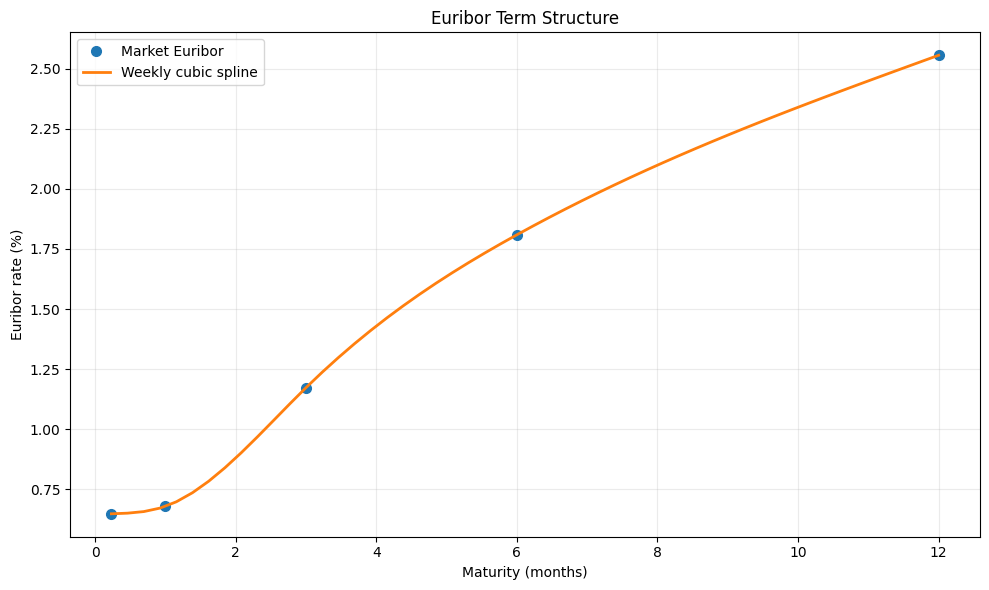

In [41]:
#Euribor market observations and weekly cubic spline.

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    euribor_maturities*12,
    euribor_rates*100,
    "o",
    markersize=7,
    label="Market Euribor"
)

ax.plot(
    weekly_T*12,
    weekly_rates*100,
    linewidth=2,
    label="Weekly cubic spline"
)

ax.set_title("Euribor Term Structure")
ax.set_xlabel("Maturity (months)")
ax.set_ylabel("Euribor rate (%)")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 14. CIR model

The CIR model was introduced by Cox, Ingersoll, and Ross (1985) as a term-structure model.


In [42]:
def cir_zcb(r0, kappa, theta, sigma, T):
    gamma = np.sqrt(
        kappa**2 + 2*sigma**2
    )

    numerator = (
        2*gamma
        * np.exp((kappa+gamma)*T/2)
    )

    denominator = (
        2*gamma
        + (kappa+gamma)
        * (np.exp(gamma*T)-1)
    )

    A = (
        numerator/denominator
    ) ** (
        2*kappa*theta/sigma**2
    )

    B = (
        2*(np.exp(gamma*T)-1)
        / denominator
    )

    return A*np.exp(-B*r0)


def cir_zero_rate(
    r0, kappa, theta, sigma, T
):
    P = cir_zcb(
        r0, kappa, theta, sigma, T
    )

    return -np.log(P)/T


### CIR calibration convention
Since the assignment asks for calibration to an interpolated **rate term structure**, the objective below minimizes squared errors between the model continuously-compounded zero rates and the interpolated weekly rates:


In [43]:
def cir_rate_mse(params, maturities, market_rates):
    r0, kappa, theta, sigma = params

    if (
        r0 <= 0
        or kappa <= 0
        or theta <= 0
        or sigma <= 0
    ):
        return 1e10

    model_rates = np.array([
        cir_zero_rate(
            r0, kappa, theta, sigma, T
        )
        for T in maturities
    ])

    return np.mean(
        (model_rates-market_rates)**2
    )


CIR_BOUNDS = [
    (1e-6, 0.10),  # r0
    (0.01, 10.0),  # kappa
    (1e-6, 0.15), # theta
    (1e-4, 0.50)  # sigma
]


In [44]:
# Multi-start CIR calibration.

cir_starts = [
    [0.0065, 0.5, 0.03, 0.03],
    [0.0070, 1.0, 0.04, 0.04],
    [0.0080, 2.0, 0.05, 0.06],
    [0.0050, 4.0, 0.06, 0.08]
]

cir_results = []

for x0 in cir_starts:
    result = minimize(
        cir_rate_mse,
        x0=x0,
        args=(weekly_T, weekly_rates),
        method="L-BFGS-B",
        bounds=CIR_BOUNDS,
        options={"maxiter": 1000, "ftol": 1e-12}
    )

    cir_results.append(result)

best_cir = min(
    cir_results,
    key=lambda x: x.fun
)

cir_params = best_cir.x
r0_cir, kappa_cir, theta_cir, sigma_cir = cir_params

cir_parameter_table = pd.DataFrame({
    "Parameter": ["r0", "kappa", "theta", "sigma"],
    "Estimate": cir_params
})

display(cir_parameter_table)

print("CIR MSE:", best_cir.fun)
print("CIR RMSE:", np.sqrt(best_cir.fun))

feller_lhs_cir = 2*kappa_cir*theta_cir
feller_rhs_cir = sigma_cir**2

print(
    f"Feller LHS = {feller_lhs_cir:.8f}; "
    f"RHS = {feller_rhs_cir:.8f}"
)
print(
    "Feller condition satisfied:",
    feller_lhs_cir > feller_rhs_cir
)


,Parameter,Estimate
0,r0,0.003959
1,kappa,1.999902
2,theta,0.041917
3,sigma,0.060002


CIR MSE: 1.7370121971707038e-07
CIR RMSE: 0.00041677478296685657
Feller LHS = 0.16766108; RHS = 0.00360019
Feller condition satisfied: True


In [45]:
# CIR fitted curve table.

cir_fitted_rates = np.array([
    cir_zero_rate(
        r0_cir,
        kappa_cir,
        theta_cir,
        sigma_cir,
        T
    )
    for T in weekly_T
])

cir_fit = pd.DataFrame({
    "Maturity (years)": weekly_T,
    "Spline rate": weekly_rates,
    "CIR rate": cir_fitted_rates,
    "Error": cir_fitted_rates-weekly_rates
})

display(cir_fit.head(10))

print("Maximum absolute weekly-rate error:",
      cir_fit["Error"].abs().max())


,Maturity (years),Spline rate,CIR rate,Error
0,0.019231,0.006480,0.004680,-0.001800
1,0.038462,0.006506,0.005382,-0.001124
2,0.057692,0.006572,0.006067,-0.000505
3,0.076923,0.006717,0.006735,0.000017
4,0.096154,0.006978,0.007386,0.000408
5,0.115385,0.007357,0.008020,0.000663
6,0.134615,0.007836,0.008639,0.000803
7,0.153846,0.008396,0.009243,0.000847
8,0.173077,0.009017,0.009832,0.000815
9,0.192308,0.009680,0.010406,0.000726


Maximum absolute weekly-rate error: 0.0018002096840864842


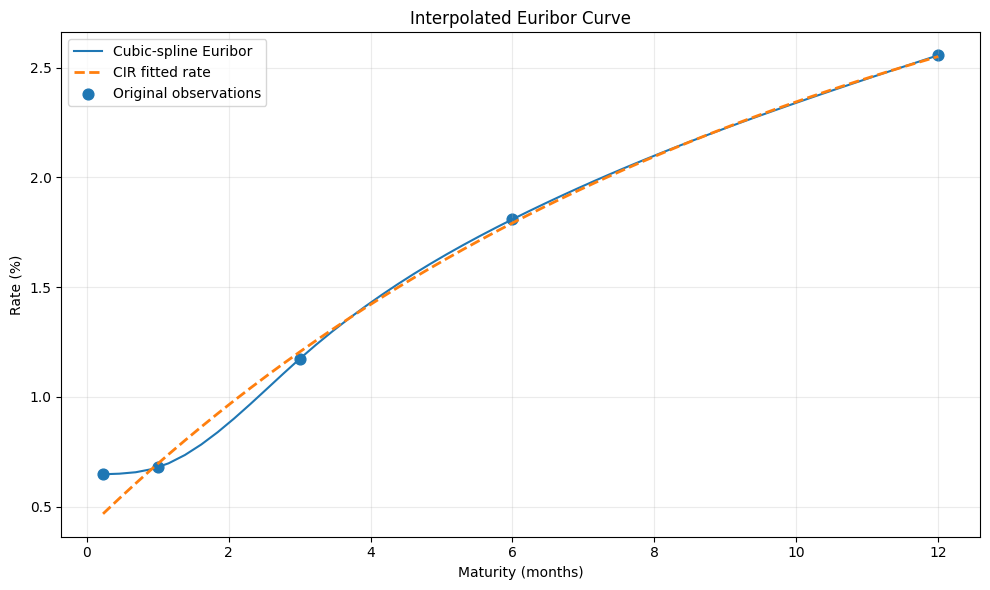

In [46]:
#CIR fitted curve versus interpolated market curve.

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    weekly_T*12,
    weekly_rates*100,
    label="Cubic-spline Euribor"
)

ax.plot(
    weekly_T*12,
    cir_fitted_rates*100,
    linestyle="--",
    linewidth=2,
    label="CIR fitted rate"
)

ax.scatter(
    euribor_maturities*12,
    euribor_rates*100,
    s=60,
    label="Original observations"
)

ax.set_title("Interpolated Euribor Curve")
ax.set_xlabel("Maturity (months)")
ax.set_ylabel("Rate (%)")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 15. Step 3(b) — 100,000 CIR Monte Carlo simulations

Daily simulation over one year using 100,000 paths. We use 250 daily steps because the project defines one year as 250 trading days.


The terminal distribution answers the three questions in the assignment:
1. a plausible range of the future 12-month Euribor;
2. its expected value after one year;
3. the implication relative to today's 12-month Euribor.


In [47]:
def simulate_cir_terminal(
    params,
    n_paths=100_000,
    n_steps=250,
    seed=2028
):
    r0, kappa, theta, sigma = params

    dt = 1/n_steps
    rng = np.random.default_rng(seed)

    rates = np.full(
        n_paths,
        r0,
        dtype=float
    )

    for _ in range(n_steps):
        z = rng.standard_normal(n_paths)

        r_pos = np.maximum(rates, 0)

        rates = (
            rates
            + kappa*(theta-r_pos)*dt
            + sigma*np.sqrt(r_pos*dt)*z
        )

        rates = np.maximum(rates, 0)

    return rates


terminal_rates = simulate_cir_terminal(
    cir_params,
    n_paths=100_000,
    n_steps=250,
    seed=2028
)

expected_12m_1y = terminal_rates.mean()

ci_level = 0.95
lower_q = (1-ci_level)/2
upper_q = 1-lower_q

lower_rate = np.quantile(
    terminal_rates,
    lower_q
)

upper_rate = np.quantile(
    terminal_rates,
    upper_q
)

current_12m = euribor_rates[-1]

change_decimal = (
    expected_12m_1y-current_12m
)

change_bps = change_decimal*10_000

cir_simulation_summary = pd.DataFrame({
    "Measure": [
        "Expected 12-month Euribor in 1 year",
        "Lower 95% bound",
        "Upper 95% bound",
        "Current 12-month Euribor",
        "Expected change",
        "Expected change (basis points)"
    ],
    "Value": [
        expected_12m_1y,
        lower_rate,
        upper_rate,
        current_12m,
        change_decimal,
        change_bps
    ]
})

display(cir_simulation_summary)

print(f"Expected rate: {expected_12m_1y:.4%}")
print(f"95% range: [{lower_rate:.4%}, {upper_rate:.4%}]")
print(f"Current 12M Euribor: {current_12m:.4%}")
print(f"Expected change: {change_bps:.1f} basis points")


,Measure,Value
0,Expected 12-month Euribor in 1 year,0.036816
1,Lower 95% bound,0.026984
2,Upper 95% bound,0.048209
3,Current 12-month Euribor,0.025560
4,Expected change,0.011256
5,Expected change (basis points),112.556983


Expected rate: 3.6816%
95% range: [2.6984%, 4.8209%]
Current 12M Euribor: 2.5560%
Expected change: 112.6 basis points


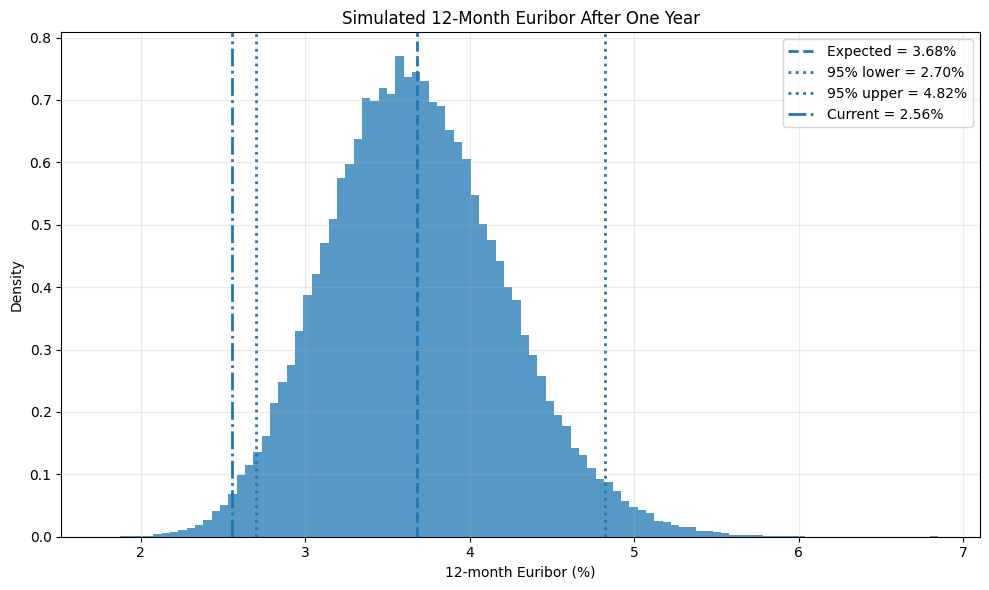

In [48]:
#Terminal distribution of 12-month Euribor.

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    terminal_rates*100,
    bins=100,
    density=True,
    alpha=0.75
)

ax.axvline(
    expected_12m_1y*100,
    linestyle="--",
    linewidth=2,
    label=f"Expected = {expected_12m_1y:.2%}"
)

ax.axvline(
    lower_rate*100,
    linestyle=":",
    linewidth=2,
    label=f"95% lower = {lower_rate:.2%}"
)

ax.axvline(
    upper_rate*100,
    linestyle=":",
    linewidth=2,
    label=f"95% upper = {upper_rate:.2%}"
)

ax.axvline(
    current_12m*100,
    linestyle="-.",
    linewidth=2,
    label=f"Current = {current_12m:.2%}"
)

ax.set_title(
    "Simulated 12-Month Euribor After One Year"
)
ax.set_xlabel("12-month Euribor (%)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 16. Interpretation of Step 3

The terminal simulation provides a distribution rather than a single forecast. The selected 95% interval is interpreted as a model-based range of plausible one-year-ahead 12-month Euribor outcomes. It should not be interpreted as a guarantee that the future rate will remain inside the interval.

For pricing, the key comparison is between the simulated expected one-year-ahead 12-month Euribor and today's 12-month Euribor. A higher expected future rate implies higher funding/discounting rates for products whose values are exposed to future interest rates, although the precise valuation effect depends on the direction and timing of each product's cash flows.
